In [14]:
from __future__ import annotations

from operator import add
from typing import TypedDict,Annotated,List

from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END, add_messages
from langgraph.types import Send

from pathlib import Path
import re

from langchain_openai import ChatOpenAI
from langchain.messages import SystemMessage,HumanMessage

from dotenv import load_dotenv
load_dotenv()

True

`from __future__ import annotations` does not throw error when you instantiate a class that is not yet defined. It does not perform validations (accross type hinting) at runtime rather store them as strings and perform them later. 

Example: In the below example there are two classes referencing each other. When we are creating the class profile the User has not been created but yet used in the during the creation of profile.
```
from __future__ import annotations
class profile:
    def __init__(self,user: User):
        self.user = user
        
class User:
    def __init__(self,profile: Profile):
        self.profile = Profile
```


About the project: We will take the `state['topic']` from the user, according to which orchestrator will create a plan. This plan will contain some N numbers of tasks which will be executed by N number of worker nodes each creating a section (task) of the blog. The output of each worker is stored inside the section. These individual sections are then combined by a reducer and presented as .md file.

In [15]:
class Task(BaseModel):
    id:str
    title: str
    brief:str = Field(..., description="What to cover") # ... means mandatory field; if not present here still same

In [16]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [17]:
class State(TypedDict):
    topic: str 
    plan : Plan
    sections : Annotated[List[str],add]
    final: str

`operator.add` is a reducer function that will concatenate the result(str) from each worker inside the list called sections. 

In [18]:
model = ChatOpenAI(model = "gpt-4.1-mini-2025-04-14")

In [19]:
def orchestrator(state: State) -> dict:
    plan = model.with_structured_output(Plan).invoke(
        [
            SystemMessage(content = " Create a blog plan with 5-7 sections on the follwing topic"),
            HumanMessage(content = f"topic = {state['topic']} "),
        ]
    )
    return {"plan":plan}

Now, we have tasks defined inside the our plan, we need to spawn the worker nodes which we can do using the Send function. Fanout is only a helper function to spawn worker nodes. It is not actually a node itself.

In [20]:
def fanout(state: State) -> List:
    sends = []
    for task in state['plan'].tasks:
        sends.append(Send("worker",arg= {"task":task, "plan": state['plan'], "topic":state['topic']}))
    return sends

In [21]:
def worker(payload:dict)-> dict:

    task = payload['task']
    topic = payload['topic']
    plan = payload['plan']

    blog_title = plan.blog_title

    section_md = model.invoke(
        [
            SystemMessage(content = "Write one clean Markdown Section"),
            HumanMessage(
                content = (
                    f"Topic: {topic}\n\n"
                    f"Blog Title: {blog_title}\n"
                    f"Section:{task.title}\n"
                    f"Brief: {task.brief}\n"
                    "Return only the section content in Markdown."
                )
            )
        ]
    ).content.strip()

    return {"sections":[section_md]}

In [ ]:
def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # Create safe filename, anything that is not a-z or A-Z or 0-9 and -,_ replace with _
    safe_title = re.sub(r'[^a-zA-Z0-9_-]', '_', title.lower())

    output_dir = Path("test_blogs")
    output_dir.mkdir(parents=True, exist_ok=True)

    output_path = output_dir / f"{safe_title}.md"
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [23]:
builder = StateGraph(State)
builder.add_node("orchestrator",action = orchestrator) # Name, fucntion or runnable this node will run
builder.add_node("worker",worker)
builder.add_node("reducer",reducer)

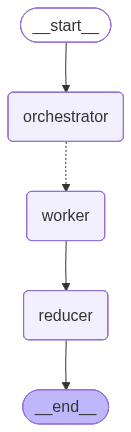

In [24]:
builder.add_edge(START,"orchestrator")
builder.add_conditional_edges("orchestrator",fanout,["worker"]) # orchestrator -> fanout -> List of worker nodes
builder.add_edge("worker","reducer")
builder.add_edge("reducer",END)

graph = builder.compile()
graph


In [25]:
response = graph.invoke({"topic":"Write a blog on Self attention"})

In [26]:
response

{'topic': 'Write a blog on Self attention',
 'plan': Plan(blog_title='Understanding Self-Attention: A Key Mechanism in Modern Neural Networks', tasks=[Task(id='1', title='Introduction to Self-Attention', brief='Explain what self-attention is and why it is important in neural networks, especially in natural language processing.'), Task(id='2', title='Historical Context and Evolution', brief='Discuss the evolution of attention mechanisms and how self-attention emerged as a powerful technique replacing traditional recurrent models.'), Task(id='3', title='How Self-Attention Works', brief='Provide a detailed explanation of the self-attention mechanism, including its components like queries, keys, and values, with illustrative examples.'), Task(id='4', title='Self-Attention in Transformer Architectures', brief='Describe how self-attention is implemented in Transformer models and its role in enabling parallel processing and handling long-range dependencies.'), Task(id='5', title='Advantages a